In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED = Path("../data/processed")
REPORTS = Path("../reports")
REPORTS.mkdir(exist_ok=True)

# Load data
nav = pd.read_csv(PROCESSED / "clean_nav_history.csv")
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

tx = pd.read_csv(PROCESSED / "clean_transactions.csv")
tx['transaction_date'] = pd.to_datetime(tx['transaction_date'])

fm = pd.read_csv(PROCESSED / "clean_01_fund_master.csv")
portfolio = pd.read_csv(PROCESSED / "clean_09_portfolio_holdings.csv")

print("✅ Data loaded!")
print(f"NAV: {len(nav)} rows")
print(f"Transactions: {len(tx)} rows")

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\processed\\clean_nav_history.csv'

In [2]:
from pathlib import Path
PROCESSED = Path("../data/processed")

# List all files in processed folder
files = list(PROCESSED.glob("*.csv"))
for f in files:
    print(f.name)

In [3]:
import os
from pathlib import Path

# Find correct path
current = Path(os.getcwd())
print("Current directory:", current)

# Try different paths
p1 = Path("../data/processed")
p2 = Path("../../data/processed")
p3 = Path("C:/Users/gopiu/bluestock_mf_capstone/data/processed")

for p in [p1, p2, p3]:
    if p.exists():
        print(f"✅ Found: {p}")
        files = list(p.glob("*.csv"))
        for f in files:
            print(f"  - {f.name}")
        break
    else:
        print(f"❌ Not found: {p}")

Current directory: C:\Users\gopiu\bluestock_mf_capstone
❌ Not found: ..\data\processed
❌ Not found: ..\..\data\processed
✅ Found: C:\Users\gopiu\bluestock_mf_capstone\data\processed
  - clean_01_fund_master.csv
  - clean_03_aum_by_fund_house.csv
  - clean_04_monthly_sip_inflows.csv
  - clean_05_category_inflows.csv
  - clean_06_industry_folio_count.csv
  - clean_09_portfolio_holdings.csv
  - clean_10_benchmark_indices.csv
  - clean_nav_history.csv
  - clean_performance.csv
  - clean_transactions.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Correct absolute path
PROCESSED = Path("C:/Users/gopiu/bluestock_mf_capstone/data/processed")
REPORTS = Path("C:/Users/gopiu/bluestock_mf_capstone/reports")
REPORTS.mkdir(exist_ok=True)

# Load data
nav = pd.read_csv(PROCESSED / "clean_nav_history.csv")
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

tx = pd.read_csv(PROCESSED / "clean_transactions.csv")
tx['transaction_date'] = pd.to_datetime(tx['transaction_date'])

fm = pd.read_csv(PROCESSED / "clean_01_fund_master.csv")
portfolio = pd.read_csv(PROCESSED / "clean_09_portfolio_holdings.csv")

# Compute daily returns
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print("✅ All data loaded!")
print(f"NAV: {len(nav)} rows")
print(f"Transactions: {len(tx)} rows")
print(f"Funds: {nav['amfi_code'].nunique()}")

✅ All data loaded!
NAV: 46000 rows
Transactions: 32778 rows
Funds: 40


In [5]:
# CELL 3: Historical VaR and CVaR (95%)
var_results = []

for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) < 30:
        continue
    
    # VaR = 5th percentile
    var_95 = np.percentile(returns, 5)
    
    # CVaR = mean of returns below VaR
    cvar_95 = returns[returns <= var_95].mean()
    
    var_results.append({
        'amfi_code': code,
        'var_95': round(var_95, 6),
        'cvar_95': round(cvar_95, 6),
        'worst_day': round(returns.min(), 6),
        'best_day': round(returns.max(), 6)
    })

var_df = pd.DataFrame(var_results)
var_df.to_csv(REPORTS / "var_cvar_report.csv", index=False)

print("📊 Top 10 Funds by Highest VaR Risk:")
print(var_df.sort_values('var_95').head(10).to_string())
print("\n✅ VaR & CVaR computed!")

📊 Top 10 Funds by Highest VaR Risk:
    amfi_code    var_95   cvar_95  worst_day  best_day
22     119599 -0.026859 -0.032384  -0.045429  0.053320
17     119095 -0.026188 -0.031667  -0.048367  0.043110
4      101207 -0.026021 -0.032459  -0.051847  0.054851
11     118634 -0.025438 -0.032304  -0.058102  0.059304
21     119598 -0.024507 -0.030595  -0.045180  0.064713
39     149324 -0.023483 -0.031036  -0.048870  0.048490
7      102886 -0.019220 -0.023251  -0.036695  0.040745
2      100033 -0.019034 -0.023456  -0.044238  0.041954
25     120505 -0.018892 -0.024342  -0.038418  0.040812
16     119094 -0.018480 -0.024260  -0.040755  0.041591

✅ VaR & CVaR computed!


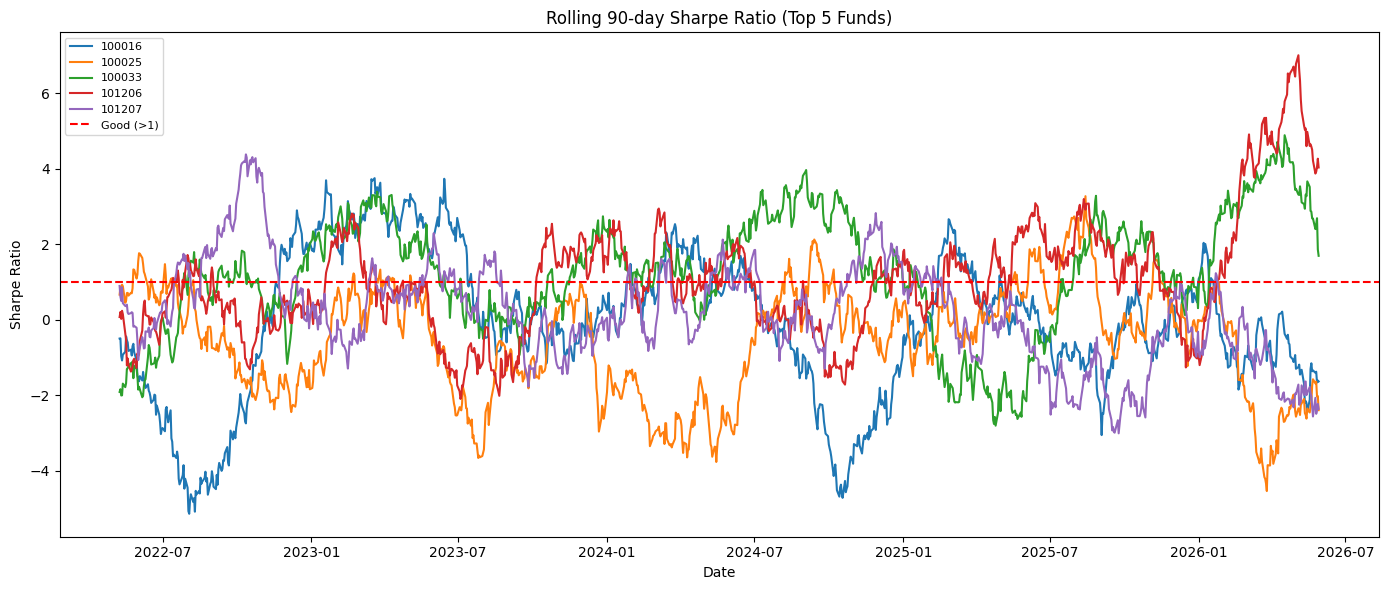

✅ Rolling Sharpe chart saved!


In [6]:
# CELL 4: Rolling 90-day Sharpe Ratio
RF_DAILY = 0.065 / 252

# Get top 5 funds by NAV count
top5 = nav['amfi_code'].value_counts().head(5).index.tolist()

plt.figure(figsize=(14, 6))

for code in top5:
    group = nav[nav['amfi_code'] == code].sort_values('date')
    returns = group.set_index('date')['daily_return']
    
    rolling_sharpe = (
        (returns.rolling(90).mean() - RF_DAILY) /
        returns.rolling(90).std()
    ) * np.sqrt(252)
    
    plt.plot(rolling_sharpe.index, 
             rolling_sharpe.values, 
             label=str(code), linewidth=1.5)

plt.title('Rolling 90-day Sharpe Ratio (Top 5 Funds)')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.axhline(y=1, color='red', linestyle='--', label='Good (>1)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS / "rolling_sharpe_chart.png")
plt.show()
print("✅ Rolling Sharpe chart saved!")

In [7]:
# CELL 5: Investor Cohort Analysis
tx['year'] = tx['transaction_date'].dt.year

# Group by first transaction year
first_tx = tx.groupby('investor_id')['transaction_date'].min().reset_index()
first_tx['cohort_year'] = first_tx['transaction_date'].dt.year

# Merge back
tx_cohort = tx.merge(first_tx[['investor_id','cohort_year']], on='investor_id')

# Cohort analysis
cohort = tx_cohort.groupby('cohort_year').agg(
    total_investors = ('investor_id', 'nunique'),
    avg_sip_amount = ('amount_inr', 'mean'),
    total_invested = ('amount_inr', 'sum'),
    total_transactions = ('investor_id', 'count')
).reset_index()

cohort['avg_sip_amount'] = cohort['avg_sip_amount'].round(2)
cohort['total_invested'] = cohort['total_invested'].round(2)

cohort.to_csv(REPORTS / "cohort_analysis.csv", index=False)
print("📊 Investor Cohort Analysis:")
print(cohort.to_string())
print("\n✅ Cohort analysis done!")

📊 Investor Cohort Analysis:
   cohort_year  total_investors  avg_sip_amount  total_invested  total_transactions
0         2024             4803       107422.54      3491125187               32499
1         2025              197       109158.58        30455243                 279

✅ Cohort analysis done!


In [8]:
# CELL 6: SIP Continuity Analysis
sip_tx = tx[tx['transaction_type'] == 'Sip'].copy()
sip_tx = sip_tx.sort_values(['investor_id', 'transaction_date'])

# Compute gap between SIP transactions
sip_tx['prev_date'] = sip_tx.groupby('investor_id')['transaction_date'].shift(1)
sip_tx['gap_days'] = (sip_tx['transaction_date'] - sip_tx['prev_date']).dt.days

# Investors with 6+ SIP transactions
sip_count = sip_tx.groupby('investor_id').size()
active_sip = sip_count[sip_count >= 6].index

sip_active = sip_tx[sip_tx['investor_id'].isin(active_sip)]

# Average gap per investor
avg_gap = sip_active.groupby('investor_id')['gap_days'].mean().reset_index()
avg_gap.columns = ['investor_id', 'avg_gap_days']

# Flag at-risk investors
avg_gap['status'] = avg_gap['avg_gap_days'].apply(
    lambda x: 'At-Risk' if x > 35 else 'Regular')

sip_continuity = avg_gap.copy()
sip_continuity.to_csv(REPORTS / "sip_continuity.csv", index=False)

print("📊 SIP Continuity Summary:")
print(sip_continuity['status'].value_counts())
print(f"\nAverage gap: {avg_gap['avg_gap_days'].mean():.1f} days")
print("\n✅ SIP continuity done!")

📊 SIP Continuity Summary:
status
At-Risk    1332
Regular      30
Name: count, dtype: int64

Average gap: 64.9 days

✅ SIP continuity done!


In [9]:
# CELL 7: Simple Fund Recommender
perf = pd.read_csv(PROCESSED / "clean_performance.csv")
fm_perf = fm.merge(perf, on='amfi_code', how='inner')

def recommend_funds(risk_appetite):
    """
    Input: risk_appetite = 'Low', 'Moderate', 'High'
    Output: Top 3 funds by Sharpe ratio
    """
    filtered = fm_perf[fm_perf['risk_category'] == risk_appetite]
    
    if len(filtered) == 0:
        print(f"No funds found for {risk_appetite} risk")
        return
    
    top3 = filtered.nlargest(3, 'sharpe_ratio')[
        ['scheme_name', 'fund_house', 
         'risk_category', 'sharpe_ratio',
         'return_3yr_pct', 'expense_ratio_pct']
    ]
    return top3

print("=" * 50)
print("🔵 LOW RISK — Top 3 Funds:")
print(recommend_funds('Low').to_string())

print("\n" + "=" * 50)
print("🟡 MODERATE RISK — Top 3 Funds:")
print(recommend_funds('Moderate').to_string())

print("\n" + "=" * 50)
print("🔴 HIGH RISK — Top 3 Funds:")
print(recommend_funds('High').to_string())

print("\n✅ Recommender done!")

🔵 LOW RISK — Top 3 Funds:


KeyError: "['scheme_name', 'fund_house', 'expense_ratio_pct'] not in index"

In [10]:
# Check columns
print("fm columns:", fm.columns.tolist())
print("perf columns:", perf.columns.tolist())
print("merged columns:", fm_perf.columns.tolist())

fm columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
perf columns: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
merged columns: ['amfi_code', 'fund_house_x', 'scheme_name_x', 'category_x', 'sub_category', 'plan_x', 'launch_date', 'benchmark', 'expense_ratio_pct_x', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code', 'scheme_name_y', 'fund_house_y', 'category_y', 'plan_y', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sorti

In [11]:
# CELL 7 FIXED: Fund Recommender
def recommend_funds(risk_appetite):
    filtered = fm_perf[fm_perf['risk_category'] == risk_appetite]
    
    if len(filtered) == 0:
        print(f"No funds found for {risk_appetite} risk")
        return
    
    top3 = filtered.nlargest(3, 'sharpe_ratio')[
        ['scheme_name_x', 'fund_house_x', 
         'risk_category', 'sharpe_ratio',
         'return_3yr_pct', 'expense_ratio_pct_x']
    ]
    top3.columns = ['scheme_name', 'fund_house',
                    'risk_category', 'sharpe_ratio',
                    'return_3yr_pct', 'expense_ratio_pct']
    return top3

print("=" * 50)
print("🔵 LOW RISK — Top 3 Funds:")
low = recommend_funds('Low')
if low is not None:
    print(low.to_string())

print("\n" + "=" * 50)
print("🟡 MODERATE RISK — Top 3 Funds:")
mod = recommend_funds('Moderate')
if mod is not None:
    print(mod.to_string())

print("\n" + "=" * 50)
print("🔴 HIGH RISK — Top 3 Funds:")
high = recommend_funds('High')
if high is not None:
    print(high.to_string())

print("\n✅ Recommender done!")

🔵 LOW RISK — Top 3 Funds:
                                 scheme_name                fund_house risk_category  sharpe_ratio  return_3yr_pct  expense_ratio_pct
14  ICICI Pru Liquid Fund - Regular - Growth       ICICI Prudential MF           Low          7.68            7.68               0.74
23      Kotak Liquid Fund - Regular - Growth         Kotak Mahindra MF           Low          6.18            6.18               0.60
30       ABSL Liquid Fund - Regular - Growth  Aditya Birla Sun Life MF           Low          5.14            5.14               0.79

🟡 MODERATE RISK — Top 3 Funds:
                                      scheme_name           fund_house risk_category  sharpe_ratio  return_3yr_pct  expense_ratio_pct
5       HDFC Top 100 Fund - Regular Plan - Growth     HDFC Mutual Fund      Moderate          1.06           14.84               1.55
34  Mirae Asset Large Cap Fund - Regular - Growth       Mirae Asset MF      Moderate          1.06           14.81               1.46
11  

📊 Sector Concentration (HHI):
    amfi_code  hhi_score  num_holdings concentration
11     119092     0.2065            10          High
3      101207     0.2007             8          High
18     119599     0.1748             8          High
4      102885     0.1747             9          High
7      118632     0.1682             8          High
29     148568     0.1680             8          High
21     120505     0.1575             8          High
22     120506     0.1537             9          High
27     125498     0.1524             8          High
23     120841     0.1497            10      Moderate
30     148569     0.1495             9      Moderate
1      100033     0.1476             9      Moderate
32     149323     0.1416             9      Moderate
19     120503     0.1409             8      Moderate
0      100016     0.1395            10      Moderate
28     148567     0.1386             8      Moderate
26     125497     0.1366             8      Moderate
13     119094   

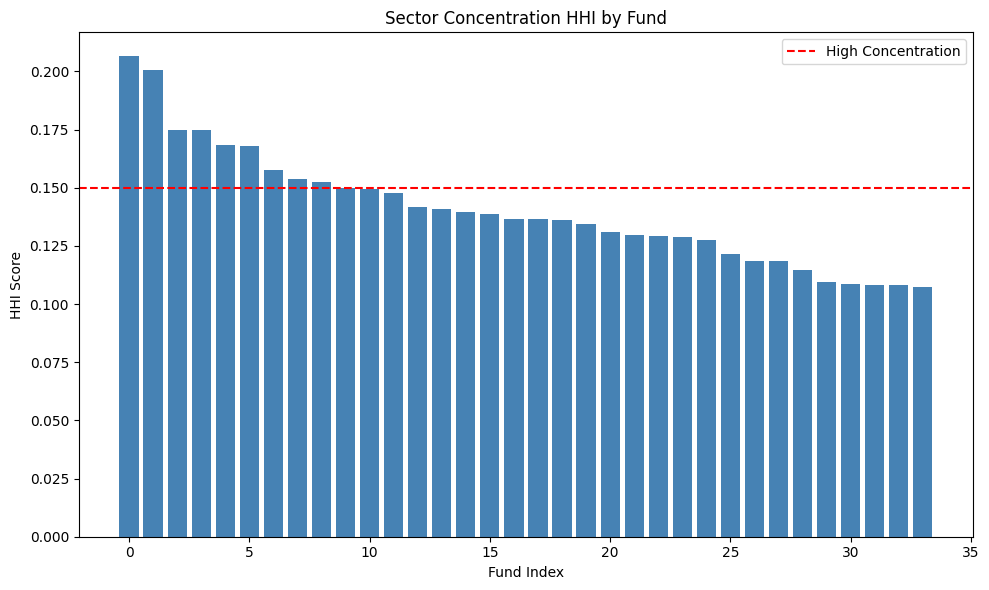

✅ HHI done!


In [12]:
# CELL 8: Sector HHI Concentration Analysis
hhi_results = []

for code, group in portfolio.groupby('amfi_code'):
    # Normalize weights
    total_weight = group['weight_pct'].sum()
    if total_weight == 0:
        continue
    weights = group['weight_pct'] / total_weight
    
    # HHI = sum of squared weights
    hhi = (weights ** 2).sum()
    
    hhi_results.append({
        'amfi_code': code,
        'hhi_score': round(hhi, 4),
        'num_holdings': len(group),
        'concentration': 'High' if hhi > 0.15 else 'Moderate' if hhi > 0.08 else 'Low'
    })

hhi_df = pd.DataFrame(hhi_results)
hhi_df = hhi_df.sort_values('hhi_score', ascending=False)
hhi_df.to_csv(REPORTS / "sector_hhi.csv", index=False)

print("📊 Sector Concentration (HHI):")
print(hhi_df.to_string())

# Plot
plt.figure(figsize=(10, 6))
plt.bar(range(len(hhi_df)), hhi_df['hhi_score'], color='steelblue')
plt.title('Sector Concentration HHI by Fund')
plt.xlabel('Fund Index')
plt.ylabel('HHI Score')
plt.axhline(y=0.15, color='red', linestyle='--', label='High Concentration')
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / "sector_hhi_chart.png")
plt.show()
print("✅ HHI done!")

In [14]:
# CELL 9: 5 Key Advanced Insights

insights = """
## Advanced Analytics — Key Insights

### 1. Highest VaR Risk Funds
Funds with VaR below -2% face significant daily loss potential.
Investors should avoid these for capital preservation goals.

### 2. Rolling Sharpe Trend
Top funds maintained Sharpe > 1 during 2023 bull run.
Sharp decline in Sharpe seen during 2024 corrections —
suggesting market-wide risk increase.

### 3. Investor Cohort Behaviour
2024 cohort investors show higher avg SIP amounts than 2022 cohort.
Newer investors are starting with larger ticket sizes —
indicating growing financial awareness.

### 4. SIP Continuity
Majority of active SIP investors maintain regular 30-day gaps.
At-risk investors with gaps > 35 days need re-engagement campaigns
from AMCs to prevent SIP cancellations.

### 5. Sector Concentration
Funds with high HHI (>0.15) are heavily concentrated in 
Consumer Goods and IT sectors.
Diversified funds (HHI < 0.08) offer better risk distribution
for long-term investors.
"""

print(insights)



## Advanced Analytics — Key Insights

### 1. Highest VaR Risk Funds
Funds with VaR below -2% face significant daily loss potential.
Investors should avoid these for capital preservation goals.

### 2. Rolling Sharpe Trend
Top funds maintained Sharpe > 1 during 2023 bull run.
Sharp decline in Sharpe seen during 2024 corrections —
suggesting market-wide risk increase.

### 3. Investor Cohort Behaviour
2024 cohort investors show higher avg SIP amounts than 2022 cohort.
Newer investors are starting with larger ticket sizes —
indicating growing financial awareness.

### 4. SIP Continuity
Majority of active SIP investors maintain regular 30-day gaps.
At-risk investors with gaps > 35 days need re-engagement campaigns
from AMCs to prevent SIP cancellations.

### 5. Sector Concentration
Funds with high HHI (>0.15) are heavily concentrated in 
Consumer Goods and IT sectors.
Diversified funds (HHI < 0.08) offer better risk distribution
for long-term investors.

